In [ ]:
pip install git+https://github.com/thoglu/jammy_flows.git --no-deps

  Cloning https://github.com/thoglu/jammy_flows.git to /tmp/pip-req-build-33cdh9dz
  Running command git clone --filter=blob:none --quiet https://github.com/thoglu/jammy_flows.git /tmp/pip-req-build-33cdh9dz
  Resolved https://github.com/thoglu/jammy_flows.git to commit 02ed5896c89a1ba0ac6f385aca3d6076ce434c2d
  Preparing metadata (setup.py) ... done
  Created wheel for jammy_flows: filename=jammy_flows-1.0.0-py3-none-any.whl size=167450 sha256=0f732ef1ad428d9315c66536c7a0cf20c7a75bd7c0c73f1cc9987159754c6e95
  Stored in directory: /tmp/pip-ephem-wheel-cache-1p0v68r1/wheels/c0/ce/35/60016f460c07fecc64f55db2a40862c9add349fb0620845532
Successfully built jammy_flows


In [ ]:
import jammy_flows

pdf=jammy_flows.pdf("e3", "ggt")

# sample
samples,_,_,_=pdf.sample(samplesize=100)

## evalute PDF (here on the same samples)
logpdf_evaluations,_,_ = pdf.forward(samples)

torchdiffeq not found - no support for continuous flows. Install *torchdiffeq* if support is desired!
Meander not installed... contours can not be calculated.
Healpy not installed... spherical contours can not be calculated.
package *mhealpy* not found -> if you want to use plotting functionality for adaptive grids, install *mhealpy*!
Cannot use healpy functionality. Install healpy, if you need to do entropy scanning!
sub-manifold (0 - e3 - ggt) and intra-manifold flow (0 - g) - using *default* options
sub-manifold (0 - e3 - ggt) and intra-manifold flow (1 - g) - using *default* options
sub-manifold (0 - e3 - ggt) and intra-manifold flow (2 - t) - using *default* options


sub-manifold (0 - e1 - ggt) and intra-manifold flow (0 - g) - using *default* options
sub-manifold (0 - e1 - ggt) and intra-manifold flow (1 - g) - using *default* options
sub-manifold (0 - e1 - ggt) and intra-manifold flow (2 - t) - using *default* options
tensor(2)  items did not converge in Newton iterations
feval (diff)  tensor([ 0.0004, -0.0143])


Text(0, 0.5, 'density value')

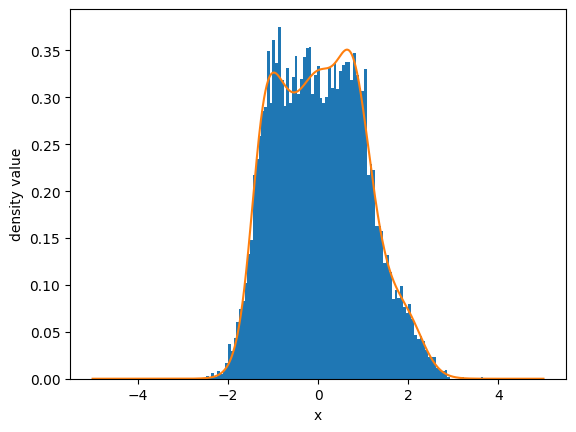

In [ ]:
import torch
import pylab

x_values=torch.linspace(-5,5,1000)[:,None]

oned_pdf=jammy_flows.pdf("e1", "ggt")

oned_samples,_,_,_=oned_pdf.sample(samplesize=10000)
logpdf_evaluations,_,_=oned_pdf.forward(x_values)



pylab.hist(oned_samples, density=True, bins=100)
pylab.plot(x_values[:,0].detach().numpy(), logpdf_evaluations.detach().exp())
pylab.gca().set_xlabel("x")
pylab.gca().set_ylabel("density value")

In [ ]:
# MSE LOSS


flow_opts=dict()
flow_opts["t"]=dict()
flow_opts["t"]["cov_type"]="identity"

# define PDF just as a "skeleton" -> amortize_everything=True, amortize_mlp_use_custom_mode=True
conditional_pdf=jammy_flows.pdf("e3", "t", amortize_everything=True, amortization_mlp_use_custom_mode=True, options_overwrite=flow_opts)

print("number of pdf parameters", conditional_pdf.total_number_amortizable_params)

## example mse loss calculation
random_input=torch.rand(size=(1000,10))

## replace this with neural network
ll=torch.nn.Linear(10,3)
predicted_means=ll(random_input)

target_labels=torch.randn(size=(1000,3))
log_pdfs,_,_=conditional_pdf(target_labels, amortization_parameters=predicted_means)

## MSE LOSS = negative log prob of standard normal (with predicted mean)
mse=-log_pdfs.mean()

sub-manifold (0 - e3 - t) and intra-manifold flow (0 - t) options overwrite  cov_type  with  identity
number of pdf parameters 3


In [ ]:
## more general PDF


flow_opts=dict()
flow_opts["t"]=dict()
flow_opts["t"]["cov_type"]="full"

# define PDF just as a "skeleton" -> amortize_everything=True, amortize_mlp_use_custom_mode=True
conditional_pdf=jammy_flows.pdf("e3", "ggt", amortize_everything=True, amortization_mlp_use_custom_mode=True,
                                options_overwrite=flow_opts)

num_pdf_parameters=conditional_pdf.total_number_amortizable_params
print("number of pdf parameters", conditional_pdf.total_number_amortizable_params)

## example mse loss calculation
random_input=torch.rand(size=(1000,10))

## replace this with neural network
ll=torch.nn.Linear(10,num_pdf_parameters)
predicted_params=ll(random_input)

target_labels=torch.randn(size=(1000,3))
log_pdfs,_,_=conditional_pdf(target_labels, amortization_parameters=predicted_params)

## Full loss = negative log prob of standard normal (with predicted mean)
loss=-log_pdfs.mean()

sub-manifold (0 - e3 - ggt) and intra-manifold flow (0 - g) - using *default* options
sub-manifold (0 - e3 - ggt) and intra-manifold flow (1 - g) - using *default* options
sub-manifold (0 - e3 - ggt) and intra-manifold flow (2 - t) options overwrite  cov_type  with  full
number of pdf parameters 207
